# Machine Learning for Financial Inclusion

*Predicting Account Ownership and Designing Evidence-Based Interventions*

---

# (A). BUSINESS UNDERSTANDING 

## 1. ***Understanding the Challenge***

Imagine two individuals:

* **Amina**, a 27-year-old fruit seller in Kisumu. She saves small amounts daily but has no bank account.
* **Joseph**, a boda boda rider in Eldoret. He uses mobile money regularly, yet has never seen the need to open a formal account.

Amina and Joseph represent millions of people across the world. Globally, about **1.4 billion adults** remain outside the formal financial system.

Why does this matter?
Without an account, people:

* Cannot save securely.
* Have limited access to credit for business or emergencies.
* Miss out on insurance, pensions, and government transfers.

Financial exclusion is not just an individual issue. It slows down economic development and limits opportunities for entire communities.

---

## 2. ***The Problem with Current Approaches***

For years, governments and financial institutions have tried to close this gap by:

* Expanding bank branches
* Reducing account fees
* Simplifying account opening procedures

These measures have helped, but they also face **three key limitations**:

1. **Inefficient Targeting** – Programs often reach people who would eventually open accounts on their own, while leaving behind those who truly face barriers.
2. **Intervention Mismatch** – Many strategies assume poverty or distance is the main issue, but evidence suggests that behaviours like saving habits or digital use may be more important.
3. **Uniform Strategies** – One-size-fits-all programs ignore that different groups face different obstacles. A rural farmer and an urban student require very different solutions.

As a result, resources are wasted, and the most excluded populations remain unreached.

---

## 3. ***Our Approach***

This project applies **machine learning** to move from assumption-driven strategies to evidence-based decisions.

We focus on four main components:

* **Prediction**: Build models to estimate an individual’s likelihood of having a financial account.
* **Driver Identification**: Determine which factors (savings, digital use, business activity, demographics) matter most.
* **Segmentation**: Group people into clusters with similar patterns, so interventions can be tailored to specific needs.
* **Actionable Insights**: Translate results into practical strategies for policymakers, financial institutions, and development organisations.

---

## 4. ***The Data***

The analysis uses the **Global Findex 2024 dataset**, covering:

* **8,476 individuals**
* **29 features** across demographics, behaviours, digital adoption, and geographic context

Examples of features:

* **Demographics**: age, gender, income group
* **Financial behaviours**: saving, borrowing, remittances
* **Digital adoption**: mobile money, internet use
* **Contextual factors**: region, rural/urban status

This dataset is large and diverse enough to build reliable predictive models and uncover meaningful patterns.

---




## 5. ***Project Objectives***

### Objective 1: *Predictive Modelling*

Build models that can predict financial account ownership with over **85% accuracy**.

### Objective 2: *Identify Drivers*

Rank the most important factors influencing financial inclusion, such as savings behaviour, mobile money use, or income.

### Objective 3: *Population Segmentation*

Use clustering methods to discover **2–6 meaningful groups** with distinct characteristics.

### Objective 4: *Recommendations*

Provide clear, evidence-based strategies for:

* Policymakers
* Financial institutions
* Development organisations

---

## 6. ***Why This Project is Different***

Most financial inclusion studies stop at describing the excluded.
This project goes further by:

* Moving from **description** to **prediction** and **action**
* Using data to **test assumptions**, not just repeat them
* Designing interventions that are **targeted**, not one-size-fits-all

---

## 7. ***In Simple Terms***

This notebook uses machine learning as a **guide**.
It will help us answer three big questions:

1. **Who** is most likely to be excluded?
2. **Why** are they excluded?
3. **What** can we do about it?

The analysis begins here, but the goal is bigger than accuracy.
It is about making financial inclusion strategies **smarter, fairer, and more impactful**.

---


# (B). DATA UNDERSTANDING

## (a). ***Set your environment.***

This code sets up the environment for **data analysis, preprocessing, and visualization**:

1. **Library Imports**  
   - **Pandas / NumPy:** For handling and manipulating structured data.  
   - **Requests:** To download or retrieve datasets from the web.  
   - **Matplotlib / Seaborn:** For creating clear, visually appealing plots and charts.  
   - **KNNImputer:** To fill missing values by finding similar data points (K-Nearest Neighbors).  
   - **LabelEncoder / StandardScaler:** For encoding categorical variables into numeric form and standardizing numeric features.

2. **Warning Control**  
   Suppresses warning messages to keep the notebook output clean.

3. **Visualization Styling**  
   Applies a consistent and professional plot style (`default` from Matplotlib) and a color palette (`Set2` from Seaborn) for better readability and aesthetics.


In [145]:
import pandas as pd               # Data manipulation and analysis
import numpy as np                # Numerical operations
import requests                    # Fetching data from URLs or APIs
import matplotlib.pyplot as plt    # Data visualization (plots, charts)
import seaborn as sns              # Advanced statistical data visualization
from sklearn.impute import KNNImputer      # Fill missing values using KNN
from sklearn.preprocessing import LabelEncoder, StandardScaler  # Encode categorical vars & standardize features
import warnings                    # Control warning messages
import ipywidgets as widgets
from IPython.display import display


warnings.filterwarnings('ignore')  # Suppress warning messages for cleaner output

# Set clean styling for plots
plt.style.use('default')           # Use Matplotlib's default style
sns.set_palette("Set2")            # Set Seaborn's color palette to 'Set2'

from sklearn.feature_selection import SelectKBest, chi2, f_classif,f_regression,mutual_info_regression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

from scipy.stats import chi2_contingency

from sklearn.impute import KNNImputer



## (b). Pipelines dropdown.


In [146]:
# Create outputs for each pipeline
out1 = widgets.Output()
out2 = widgets.Output()

# Accordion container
accordion = widgets.Accordion(children=[out1, out2])
accordion.set_title(0, "📦 Missing Data Cleaning Pipeline")
accordion.set_title(1, "📦 Outlier Detection Pipeline")
display(accordion)


Accordion(children=(Output(), Output()), titles=('📦 Missing Data Cleaning Pipeline', '📦 Outlier Detection Pipe…

## (b).  ***Loading the dataset***
- Fetch the datataset
- Note: Ensure you have the correct path to the CSV file

In [147]:
# ===============================================================
#  LOADING THE DATASET + OVERVIEW
# ===============================================================


# Fetch the datataset

globalfin = pd.read_csv("GlobalFindexDatabase2025.csv")

# Display the first few rows of the DataFrame 
# named 'globalfin'
globalfin.head()

,countrynewwb,codewb,year,pop_adult,regionwb24_hi,incomegroupwb24,group,group2,account_t_d,fiaccount_t_d,...,con12m_s,con26lm_s,con12w_s,con2f_s,con13_s,con26m_s,con28lm_s,con5a_s,con17c_s,con32h_s
0,Afghanistan,AFG,2011,14575546.0,South Asia (excluding high income),Low income,all,all,0.090050,0.090050,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Albania,ALB,2011,2281010.0,Europe & Central Asia (excluding high income),Upper middle income,all,all,0.282681,0.282681,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Algeria,DZA,2011,26251587.0,Middle East & North Africa (excluding high inc...,Lower middle income,all,all,0.332861,0.332861,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Angola,AGO,2011,12779501.0,Sub-Saharan Africa (excluding high income),Lower middle income,all,all,0.392035,0.392035,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Argentina,ARG,2011,30685516.0,Latin America & Caribbean (excluding high income),Upper middle income,all,all,0.331302,0.331302,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [148]:
## Get an overview of globalfin info, and descriptive statistics
print("shape:", globalfin.shape)
print("duplicates:", globalfin.duplicated().sum())
print("\ncolumns:\n", globalfin.columns.tolist())       
print(globalfin.info())
print(globalfin.describe(include='all'))
print(globalfin.dtypes)


shape: (8566, 437)
duplicates: 0

columns:
 ['countrynewwb', 'codewb', 'year', 'pop_adult', 'regionwb24_hi', 'incomegroupwb24', 'group', 'group2', 'account_t_d', 'fiaccount_t_d', 'mobileaccount_t_d', 'borrow_any_t_d', 'fin4_d', 'dig_acc', 'fin11_2a', 'fin11a', 'fin11b', 'fin11c', 'fin11f', 'fin11d', 'fin11e', 'fin14a', 'fin14b', 'fin14c', 'fin14d', 'fin13_1a', 'fin13_1b', 'fin26a', 'fin26b', 'fin27a', 'fin27b', 'fin17f', 'fin17a_17a1_d', 'fin17a', 'fin17b', 'fin17c', 'fin22d', 'fin22e', 'fin22a_22a1_22g_d', 'fin22a', 'fin22a_1', 'fin22b', 'fin22c', 'fin24sav', 'fin24fam', 'fin24work', 'fin24bor', 'fin24sell', 'fin24other', 'fin24aVD', 'fin24aSD', 'fin24aND', 'fin24aSD_ND', 'fin24aP', 'fin24aN', 'fin24sav_SD_ND', 'fin24fam_SD_ND', 'fin24work_SD_ND', 'fin24bor_SD_ND', 'fin24sell_SD_ND', 'fin24other_SD_ND', 'fin24sav_VD', 'fin24fam_VD', 'fin24work_VD', 'fin24bor_VD', 'fin24sell_VD', 'fin24other_VD', 'fh1', 'fin28', 'fh2', 'fin29', 'fin31a_31b', 'fin30', 'fin31a', 'fin31b', 'fin31d', 'fin3

## (c). ***Global Financial Dataset Overview***

##### **1. Shape — The Size of Our Playground**
* **Rows (8,566)** → each row is one observation (could be a country in a year, or a group within a country).
* **Columns (437)** → each column is a variable (like a question in a survey).

> Big datasets like this can be powerful, but they can also be messy — the first job is to *understand the layout*.

##### **2. Column Information — What's in the Menu?**

Some important columns:

* **Identifiers** (like name tags):

  * `countrynewwb`: Country name
  * `codewb`: Short code (e.g., “KEN” for Kenya)
  * `year`: Year of observation
  * `pop_adult`: Adult population size

* **Descriptors** (categorical info):

  * `regionwb24_hi`: Region grouping (like “East Asia & Pacific”)
  * `incomegroupwb24`: World Bank income classification (High, Upper-Middle, etc.)

* **Financial Indicators**:

  * `account_t_d`: Owns an account (traditional or digital)
  * `fiaccount_t_d`: Owns a financial institution account
  * `mobileaccount_t_d`: Owns a mobile money account
  * `borrow_any_t_d`, `fin24sav`: borrowing/saving activity

* **Survey Codes** (`fin*`, `con*`):
  These are more specialised — they might represent answers to specific survey questions.

##### **3. Data Types — What Kind of Stuff Is This?**

From `.dtypes` we see:

* **Float64 (430 columns)** → decimal numbers, percentages, proportions, scores
* **Int64 (1 column)** → integers (whole numbers) — here it’s `year`
* **Object (6 columns)** → text or mixed content (country names, codes, categories)

>  Knowing data types is important because it affects what operations we can do — you can’t average a text column, but you can group by it.

---

##### **5. Descriptive Statistics**

From `.describe(include='all')` we learn:

**Time Range:**

* Earliest year: 2011
* Latest year: 2024

**Countries:**

* 174 unique countries
* Most frequent: *Mexico* (57 observations)

**Population (`pop_adult`):**

* Smallest: \~228,000 adults
* Largest: \~1.17 billion adults (India or China likely)
* Average: \~37.99 million

**Account Ownership (`account_t_d`):**

* Mean: 0.61 → On average, 61% of adults in the dataset have an account.
* Min: 0.004 → Some countries have near-zero coverage.
* Max: 1.0 → Full coverage (100% account ownership).
---

##### **6. Special Notes**

* Many columns end in `_s` → these may be *standardised*, *scaled*, or *summary* variables from raw responses.
* Some survey columns have only **1 or 2 non-null values** → these might be pilot questions, rare cases, or data errors.

##### **7. There are NO duplicates**

## (d). ***Checking on Missing values.***
- Explore the 

-       data types 
-       missing values
-       unique counts

In [149]:
# Create a summary DataFrame to show data types, missing values, and unique counts
# summary: dtype / missing / unique
summary = pd.DataFrame({
    'dtype': globalfin.dtypes.astype(str),
    'n_missing': globalfin.isnull().sum(),
    'pct_missing': globalfin.isnull().mean(),
    'n_unique': globalfin.nunique(dropna=False)
})
summary = summary.sort_values('pct_missing', ascending=False)
summary.head(20)   # show top 20 by missingness

,dtype,n_missing,pct_missing,n_unique
con32h_s,float64,8565,0.999883,2
con17c_s,float64,8565,0.999883,2
con5a_s,float64,8565,0.999883,2
fin32_33_34b_s,float64,8565,0.999883,2
con13_s,float64,8565,0.999883,2
con26m_s,float64,8565,0.999883,2
con12m_s,float64,8565,0.999883,2
con28lm_s,float64,8565,0.999883,2
fin37_38_39d_s,float64,8565,0.999883,2
fing2p_card_s,float64,8565,0.999883,2


### ***Conclusion on the missing values.***
**Observation:**

- Many columns have over 99% missing values.

- These columns might only apply to a tiny subset of the dataset.

- Some have very few unique values (e.g., 2–4), which might limit their usefulness.


**Takeaways:**

- The dataset is very wide → not all columns will be equally useful.

- A large portion of the data is missing for many variables.

Before modeling, you’ll likely need:

- **Feature selection** → drop or combine high-missingness columns.

- **Imputation** → fill missing values if they’re still important.

- **Understanding the _s columns** → check documentation to know if they’re relevant to your analysis.

# (C). ***DATA CLEANING***

## (a). ***Create Working Copy***
   - Preserve Original Data Integrity 
   - Create a working copy for exploration and transformation without altering the raw dataset.
      

In [150]:
#Create Working Copy and Basic Cleaning
# Create working copy
df = globalfin.copy()

print(f"Starting with: {df.shape}")
print(f"Target variable 'account_t_d' missing: {df['account_t_d'].isnull().sum()} ({df['account_t_d'].isnull().mean():.1%})")

Starting with: (8566, 437)
Target variable 'account_t_d' missing: 90 (1.1%)


## (b). ***Remove Metadata/Identifier Columns***

   - Eliminate Non-Predictive Metadata
   - Remove identifiers and contextual columns (e.g., country names, codes, year) that do not directly influence predictions and may cause information leakage.


In [151]:
# Columns to remove (metadata that shouldn't be used for prediction)
metadata_cols = [
    'countrynewwb',  # Country name (text)
    'codewb',        # Country code  
    'year',          # Year (could cause data leakage)
    'pop_adult'      # Population size (not individual-level)
]

# Check if these columns exist before dropping
existing_metadata = [col for col in metadata_cols if col in df.columns]
df_clean = df.drop(columns=existing_metadata)

print(f"Removed {len(existing_metadata)} metadata columns")
print(f"New shape: {df_clean.shape}")


Removed 4 metadata columns
New shape: (8566, 433)


## (c). ***Target Variable Analysis***

   - Examine Target Distribution
   - Confirm the format, range, and structure of `account_t_d` to ensure it is correctly defined for modeling.

In [152]:
# Analyze our target variable
target_stats = df_clean['account_t_d'].describe()
print("Target Variable (account_t_d) Statistics:")
print(target_stats)

# Check for valid range (should be 0-1 for proportions)
print(f"\nRange: {df_clean['account_t_d'].min():.4f} to {df_clean['account_t_d'].max():.4f}")


Target Variable (account_t_d) Statistics:
count    8476.000000
mean        0.609056
std         0.281218
min         0.004049
25%         0.374352
50%         0.619868
75%         0.875940
max         1.000000
Name: account_t_d, dtype: float64

Range: 0.0040 to 1.0000


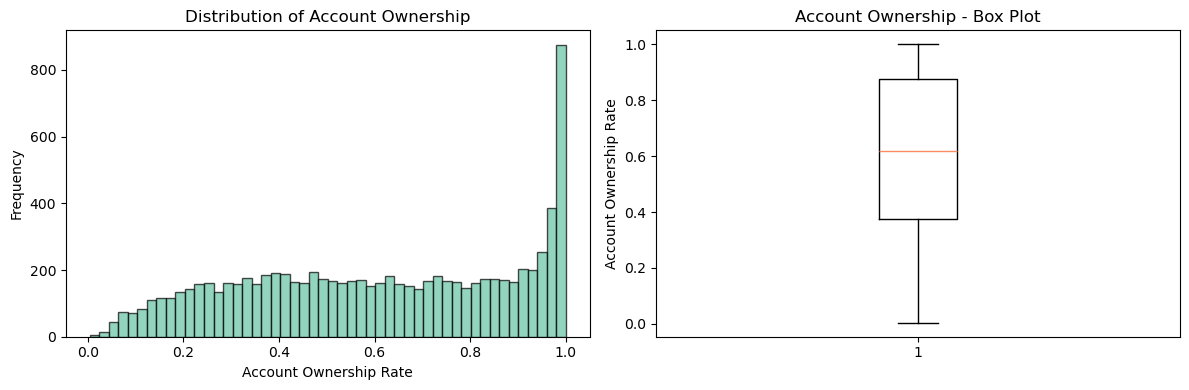

In [153]:
## Visualize the distribution of the target variable
## - Histogram
## - Box plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(df_clean['account_t_d'].dropna(), bins=50, alpha=0.7, edgecolor='black')
plt.title('Distribution of Account Ownership')
plt.xlabel('Account Ownership Rate')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.boxplot(df_clean['account_t_d'].dropna())
plt.title('Account Ownership - Box Plot')
plt.ylabel('Account Ownership Rate')

plt.tight_layout()
plt.show()

In [154]:
# Check if we have individual-level or aggregated data
print("Unique values in account_t_d (first 20):")
print(df_clean['account_t_d'].value_counts().head(20))

# Check if we have group-level data
if 'group' in df_clean.columns:
    print(f"\nGroup types: {df_clean['group'].value_counts()}")
if 'group2' in df_clean.columns:
    print(f"\nGroup2 types: {df_clean['group2'].value_counts()}")

Unique values in account_t_d (first 20):
account_t_d
1.000000    186
0.979718      2
0.651160      2
0.823221      2
0.685647      1
0.570173      1
0.871107      1
0.775988      1
0.963450      1
0.827969      1
0.634705      1
0.376106      1
0.755855      1
0.660206      1
0.879884      1
0.787895      1
0.302600      1
0.558604      1
0.528249      1
0.133531      1
Name: count, dtype: int64

Group types: group
gender        1508
age_cat       1508
education     1506
laborforce    1488
income        1482
all            771
urbanicity     303
Name: count, dtype: int64

Group2 types: group2
all                      771
men                      754
women                    754
ages 15-24               754
age 25+                  754
secondary edu or more    753
prim edu or less         753
in laborforce            744
out of laborforce        744
poorest 40%              741
richest 60%              741
urban                    152
rural                    151
Name: count, dtype: int

### ***Target Analysis Observations***

***Target Distribution Insights***

- Bimodal distribution: Heavy concentration at 1.0 (perfect inclusion) and spread across 0.4-0.8 range
- 186 observations with 100% account ownership - likely developed countries/high-income groups
- Median at 62% - shows global financial inclusion is still a work in progress
- Data is GROUP-LEVEL aggregated - not individual responses but demographic segments

***Data Structure Revelation***

- Group types: gender, age_cat, education, laborforce, income, urbanicity
- Group2 breakdown: men/women, age ranges, education levels, income quintiles
- This is **DEMOGRAPHIC SEGMENT** data - each row represents account ownership rate for a specific population group


## (d) ***Drop highly Missing Values >65% missing*** 
   - Quantify and categorize missingness, and drop features with excessive data gaps to maintain analytical reliability.
   - Group the data by how much is missing to help in decision making.
   - Remove ***393 high-missingness columns** (>65% missing) - likely country-specific questions
   - Massive dimensionality reduction: **433 → 40** features 


In [155]:
# Create detailed missingness report
def analyze_missingness(df):
    missing_info = pd.DataFrame({
        'column': df.columns,
        'missing_count': df.isnull().sum(),
        'missing_pct': df.isnull().mean() * 100,
        'dtype': df.dtypes.astype(str),
        'unique_values': df.nunique()
    }).sort_values('missing_pct', ascending=False)
    
    return missing_info

missing_report = analyze_missingness(df_clean)
print("Top columns by missingness:")
print(missing_report.head(5))

Top columns by missingness:
                        column  missing_count  missing_pct    dtype  \
con26m_s              con26m_s           8565    99.988326  float64   
con28lm_s            con28lm_s           8565    99.988326  float64   
con5a_s                con5a_s           8565    99.988326  float64   
con17c_s              con17c_s           8565    99.988326  float64   
fin37_38_39d_s  fin37_38_39d_s           8565    99.988326  float64   

                unique_values  
con26m_s                    1  
con28lm_s                   1  
con5a_s                     1  
con17c_s                    1  
fin37_38_39d_s              1  


In [156]:
# Categorize columns by missingness level
high_missing = missing_report[missing_report['missing_pct'] > 65]['column'].tolist()
med_missing = missing_report[(missing_report['missing_pct'] > 45) & (missing_report['missing_pct'] <= 65)]['column'].tolist()
low_missing = missing_report[missing_report['missing_pct'] <= 45]['column'].tolist()

print(f"High missingness (>65%): {len(high_missing)} columns")
print(f"Medium missingness (45-65%): {len(med_missing)} columns") 
print(f"Low missingness (<45%): {len(low_missing)} columns")

# Remove high missingness columns (>90% missing)
print(f"\nRemoving {len(high_missing)} high-missingness columns")
df_clean = df_clean.drop(columns=high_missing)
print(f"New shape: {df_clean.shape}")

High missingness (>65%): 393 columns
Medium missingness (45-65%): 18 columns
Low missingness (<45%): 22 columns

Removing 393 high-missingness columns
New shape: (8566, 40)


## (e). Numerical features variance analysis.
   - Checking which numerical columns in the dataset don’t change much (i.e., almost all the values are the same).
   - If a feature has very **low variance**, it means it gives almost no new information because it doesn’t really distinguish one data point from another.
   - Low variance analysis helps you spot and remove features with little to no variability, so that the model focuses only on meaningful information.
   - Remove **6 low variance columns** (<0.02 variance ) 
   - Significant dimensionality reduction: **40 → 34** features 

   

In [157]:
# Check variance for numerical columns
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns
variance_info = pd.DataFrame({
    'column': numerical_cols,
    'variance': df_clean[numerical_cols].var(),
    'std': df_clean[numerical_cols].std(),
    'unique_values': df_clean[numerical_cols].nunique()
}).sort_values('variance')

print("Lowest variance numerical features:")
print(variance_info.head(10))

Lowest variance numerical features:
                        column  variance       std  unique_values
fin22d                  fin22d  0.008397  0.091638           4026
fin24aSD              fin24aSD  0.008465  0.092004           3035
fin22b                  fin22b  0.015390  0.124055           6032
fin42                    fin42  0.017318  0.131599           3411
fin37                    fin37  0.017858  0.133633           3862
fin32_n33            fin32_n33  0.019389  0.139243           5778
borrow_any_t_d  borrow_any_t_d  0.021793  0.147625           6400
fin32_n33_acc    fin32_n33_acc  0.022780  0.150931           3531
fin32_n33_34a    fin32_n33_34a  0.023872  0.154506           3108
fing2p_fin          fing2p_fin  0.025068  0.158330           3615


In [158]:
# Remove near-zero variance features (e.g., <0.001 variance)
low_var_threshold = 0.02
low_var_cols = variance_info[variance_info['variance'] < low_var_threshold]['column'].tolist()

if low_var_cols:
    print(f"\nRemoving {len(low_var_cols)} low-variance columns")
    df_clean = df_clean.drop(columns=low_var_cols)
    print(f"New shape: {df_clean.shape}")


Removing 6 low-variance columns
New shape: (8566, 34)


## (e). ***Correlation Analysis***
  
   - Correlation analysis with the target variable measures how strongly each feature relates to the outcome.
   - Features with higher correlation often have stronger predictive power.  
   - Extremely high correlation (≥0.9) may indicate data leakage rather than true prediction. 
   - The goal is to keep genuine predictors while dropping redundant or leaking features.
   - Remove **5 highly correlated columns** (>89% correlation ) 
   - Significant dimensionality reduction: **34 → 29** features 
 



In [159]:
#Identify Potential Leakage Variables
# Look for variables that might leak information about the target
# These often have names suggesting they measure financial behavior
potential_leakage = []

for col in df_clean.columns:
    if col != 'account_t_d':
        # Check correlation with target (high correlation might indicate leakage)
        if df_clean[col].dtype in ['float64', 'int64']:
            corr = df_clean[col].corr(df_clean['account_t_d'])
            if abs(corr) > 0.7:  # Very high correlation
                potential_leakage.append((col, corr))

print("Potential data leakage candidates (high correlation with target):")
for col, corr in sorted(potential_leakage, key=lambda x: abs(x[1]), reverse=True)[:10]:
    print(f"{col}: correlation = {corr:.4f}")



Potential data leakage candidates (high correlation with target):
fiaccount_t_d: correlation = 0.9591
g20_any: correlation = 0.9551
g20_made: correlation = 0.8951
fin2_t_d: correlation = 0.8950
g20_received: correlation = 0.8936
fin31a_31b: correlation = 0.7796
fin26a: correlation = 0.7671
fin31a: correlation = 0.7656
fin17a: correlation = 0.7600
fin17a_17a1_d: correlation = 0.7564


In [160]:
#drop columns with high correlation with target if corr >  0.8
for col, corr in potential_leakage:
    if abs(corr) > 0.8:
        df_clean.drop(columns=[col], inplace=True)

print(f"\nRemoved {len([1 for col, corr in potential_leakage if abs(corr) > 0.8])} potential leakage columns")
print(f"New shape: {df_clean.shape}")


Removed 5 potential leakage columns
New shape: (8566, 29)


## (f). ***Column Renaming.***

   - The columns in the dataset are being renamed to make them more **readable, consistent, and meaningful**.
   - Original technical names (e.g., `regionwb24_hi`, `fin17a`, `fing2p`) are being mapped to simpler names (e.g., `region`, `biz_loan`, `prefer_digital`).
   - This is improving **clarity**, making it easier to interpret variables during analysis. 
   - The renaming is being performed using a dictionary (`rename_map`) and applied with `df.rename(columns=rename_map)`. 
   - The final result is a clean dataframe (`df_clean`) with descriptive column names for analysis and reporting.

In [161]:
df_clean.columns

Index(['regionwb24_hi', 'incomegroupwb24', 'group', 'group2', 'account_t_d',
       'borrow_any_t_d', 'fin26a', 'fin17a_17a1_d', 'fin17a',
       'fin22a_22a1_22g_d', 'fin22a', 'fin24aSD_ND', 'fin24aP', 'fin24aN',
       'fin31a_31b', 'fin30', 'fin31a', 'fin31d', 'fin32_n33_34a',
       'fin32_n33_acc', 'fin32', 'fin32_acc', 'fin34a', 'fin37_38', 'fin10',
       'fing2p_acc', 'fing2p_fin', 'fing2p', 'save_any_t_d'],
      dtype='object')

In [162]:
rename_map = {
    'regionwb24_hi': 'region',
    'incomegroupwb24': 'income_group',
    'group': 'demo_group',
    'group2': 'demo_subgroup',
    'account_t_d': 'has_account',
    'borrow_any_t_d': 'borrowed_any',
    'fin26a': 'credit_card',
    'fin17a_17a1_d': 'biz_loan_source',
    'fin17a': 'biz_loan',
    'fin22a_22a1_22g_d': 'loan_purpose_group',
    'fin22a': 'loan_purpose',
    'fin24aSD_ND': 'saved_old_age',
    'fin24aP': 'saved_for_purchase',
    'fin24aN': 'saved_no_purpose',
    'fin31a_31b': 'mobile_pay_s_r',
    'fin30': 'digital_payment_other',
    'fin31a': 'mobile_payment',
    'fin31d': 'mobile_payment_bill',
    'fin32_n33_34a': 'govt_digital_pay',
    'fin32_n33_acc': 'govt_digital_pay_acc',
    'fin32': 'digital_pay',
    'fin32_acc': 'digital_pay_acc',
    'fin34a': 'govt_payment_recv',
    'fin37_38': 'fin_resilience',
    'fin10': 'emergency_funds',
    'fing2p_acc': 'prefer_digital_acc',
    'fing2p_fin': 'prefer_digital_fin',
    'fing2p': 'prefer_digital',
    'save_any_t_d': 'saved_any'}
df_clean = df_clean.rename(columns=rename_map)    

In [163]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8566 entries, 0 to 8565
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   region                 7882 non-null   object 
 1   income_group           7882 non-null   object 
 2   demo_group             8566 non-null   object 
 3   demo_subgroup          8566 non-null   object 
 4   has_account            8476 non-null   float64
 5   borrowed_any           6401 non-null   float64
 6   credit_card            3169 non-null   float64
 7   biz_loan_source        6191 non-null   float64
 8   biz_loan               5711 non-null   float64
 9   loan_purpose_group     4955 non-null   float64
 10  loan_purpose           4602 non-null   float64
 11  saved_old_age          3036 non-null   float64
 12  saved_for_purchase     6444 non-null   float64
 13  saved_no_purpose       5080 non-null   float64
 14  mobile_pay_s_r         3939 non-null   float64
 15  digi

# (D). ***Handling the Missing Values***

- We will use a comprehensive pipeline, that will allow us to call on each function to display the results.
- This pipeline systematically prepares the dataset for analysis and modeling by combining **domain knowledge** and **data-driven missingness checks**.




## (a). ***Understand the data***
  
   
   * Each column is mapped to its **real-world meaning** (e.g., `has_account` = access to formal or digital accounts)
   * Missing values are profiled for each column.
   * Output: A dictionary of column meanings + % missing per feature.



In [164]:
def step1_understand_the_data(df):
    """
    Step 1: Understand what each renamed column represents
    """
    print("🔍 STEP 1: UNDERSTANDING THE DATA")
    print("="*60)
    
    # Meanings for cleaned column names
    column_meanings = {
        # Demographics
        'region': 'World Bank Region',
        'income_group': 'World Bank Income Group Classification',
        'demo_group': 'Demographic Group (e.g., age, gender, education)',
        'demo_subgroup': 'Secondary Demographic Group',
        
        # Core Financial Inclusion Indicators
        'has_account': 'Has Account (Traditional/Digital) - TARGET VARIABLE',
        'borrowed_any': 'Borrowed Any Money (Traditional/Digital)',
        'saved_any': 'Saved Any Money (Traditional/Digital)',
        
        # Credit/Debt
        'credit_card': 'Has Credit Card',
        'biz_loan_source': 'Business Loan Source',
        'biz_loan': 'Business Loan Taken',
        'loan_purpose_group': 'Grouped Loan Purpose',
        'loan_purpose': 'Specific Loan Purpose',
        
        # Savings Behaviour
        'saved_old_age': 'Saved for Old Age',
        'saved_for_purchase': 'Saved for a Purchase',
        'saved_no_purpose': 'Saved Without a Purpose',
        
        # Digital/Mobile Payments
        'mobile_pay_s_r': 'Mobile Payment Sending/Receiving',
        'digital_payment_other': 'Other Digital Payment',
        'mobile_payment': 'Mobile Payment Usage',
        'mobile_payment_bill': 'Mobile Bill Payment',
        
        # Government/Institutional Services
        'govt_digital_pay': 'Government Digital Payments',
        'govt_digital_pay_acc': 'Government Digital Payments via Account',
        'digital_pay': 'Digital Payments (General)',
        'digital_pay_acc': 'Digital Payments via Account',
        'govt_payment_recv': 'Government Payment Received',
        
        # Financial Resilience
        'fin_resilience': 'Financial Resilience / Ability to Cope',
        'emergency_funds': 'Emergency Funds Availability',
        
        # Digital Preference
        'prefer_digital_acc': 'Preference for Digital - Account Services',
        'prefer_digital_fin': 'Preference for Digital - Financial Services',
        'prefer_digital': 'Preference for Digital - General'
    }
    
    print("COLUMN INTERPRETATION:")
    print("-" * 60)
    for col in df.columns:
        meaning = column_meanings.get(col, "Unknown financial indicator")
        missing_pct = (df[col].isnull().sum() / len(df)) * 100
        print(f"{col:<22} | {missing_pct:>5.1f}% missing | {meaning}")
    
    return column_meanings


In [165]:
#Step 1: Understand the data
column_meanings = step1_understand_the_data(df_clean)
    

🔍 STEP 1: UNDERSTANDING THE DATA
COLUMN INTERPRETATION:
------------------------------------------------------------
region                 |   8.0% missing | World Bank Region
income_group           |   8.0% missing | World Bank Income Group Classification
demo_group             |   0.0% missing | Demographic Group (e.g., age, gender, education)
demo_subgroup          |   0.0% missing | Secondary Demographic Group
has_account            |   1.1% missing | Has Account (Traditional/Digital) - TARGET VARIABLE
borrowed_any           |  25.3% missing | Borrowed Any Money (Traditional/Digital)
credit_card            |  63.0% missing | Has Credit Card
biz_loan_source        |  27.7% missing | Business Loan Source
biz_loan               |  33.3% missing | Business Loan Taken
loan_purpose_group     |  42.2% missing | Grouped Loan Purpose
loan_purpose           |  46.3% missing | Specific Loan Purpose
saved_old_age          |  64.6% missing | Saved for Old Age
saved_for_purchase     |  24.8% mi

## (b). ***Categorize by Business Logic***
  
* Features are grouped into meaningful **business categories**:

  * Demographics
  * Core Inclusion
  * Credit Behaviour
  * Savings Behaviour
  * Digital Payments
  * Government Services
  * Financial Resilience
  * Digital Preference
* Missingness is summarized per group to highlight sparsity trends.



In [166]:
def step2_categorize_by_business_logic(df, column_meanings):
    """
    Step 2: Categorize columns by business importance and missing data
    """
    print(f"\n🏷️  STEP 2: CATEGORIZING BY BUSINESS LOGIC")
    print("="*60)
    
    categories = {
        'demographics': ['region', 'income_group', 'demo_group', 'demo_subgroup'],
        'core_inclusion': ['has_account', 'borrowed_any', 'saved_any'],
        'credit_behavior': ['credit_card', 'biz_loan_source', 'biz_loan', 'loan_purpose_group', 'loan_purpose'],
        'savings_behavior': ['saved_old_age', 'saved_for_purchase', 'saved_no_purpose'],
        'digital_payments': ['mobile_pay_s_r', 'digital_payment_other', 'mobile_payment', 'mobile_payment_bill'],
        'govt_services': ['govt_digital_pay', 'govt_digital_pay_acc', 'digital_pay', 'digital_pay_acc', 'govt_payment_recv'],
        'financial_resilience': ['fin_resilience', 'emergency_funds'],
        'digital_preference': ['prefer_digital_acc', 'prefer_digital_fin', 'prefer_digital']
    }
    
    print("BUSINESS CATEGORY ANALYSIS:")
    print("-" * 60)
    
    for category, cols in categories.items():
        available_cols = [col for col in cols if col in df.columns]
        if available_cols:
            avg_missing = np.mean([df[col].isnull().mean() for col in available_cols]) * 100
            print(f"{category.upper():<22} | {len(available_cols)} cols | {avg_missing:>5.1f}% avg missing")
            
            for col in available_cols:
                missing_pct = df[col].isnull().mean() * 100
                meaning = column_meanings.get(col, "Unknown")
                print(f"  └─ {col:<20} | {missing_pct:>5.1f}% missing | {meaning}")
    
    return categories


In [167]:
#Step 2: Categorize by business logic
categories = step2_categorize_by_business_logic(df_clean, column_meanings)
    


🏷️  STEP 2: CATEGORIZING BY BUSINESS LOGIC
BUSINESS CATEGORY ANALYSIS:
------------------------------------------------------------
DEMOGRAPHICS           | 4 cols |   4.0% avg missing
  └─ region               |   8.0% missing | World Bank Region
  └─ income_group         |   8.0% missing | World Bank Income Group Classification
  └─ demo_group           |   0.0% missing | Demographic Group (e.g., age, gender, education)
  └─ demo_subgroup        |   0.0% missing | Secondary Demographic Group
CORE_INCLUSION         | 3 cols |  17.2% avg missing
  └─ has_account          |   1.1% missing | Has Account (Traditional/Digital) - TARGET VARIABLE
  └─ borrowed_any         |  25.3% missing | Borrowed Any Money (Traditional/Digital)
  └─ saved_any            |  25.4% missing | Saved Any Money (Traditional/Digital)
CREDIT_BEHAVIOR        | 5 cols |  42.5% avg missing
  └─ credit_card          |  63.0% missing | Has Credit Card
  └─ biz_loan_source      |  27.7% missing | Business Loan Source
 

## (c). ***Missing Data Strategy***


* For each category, we are defining how to treat missing values using **business logic** from **step 2** and the **proportion of missingness**.


  * **Demographics** → Missing means *unknown profile*. If sparse → **drop**, else → **fill with mode**.
  * **Core Inclusion** → These are **key indicators**; missing means *no activity* → **fill with 0**.
  * **Digital Payments** → If not reported, assume *non-usage*. If moderate missingness → **0 + indicator**; if too sparse → **drop**. 
  * **Savings Behaviour** → Same as digital; missing = *no savings*. Apply **0 + indicator** or **drop** if very sparse.
  * **Credit Behaviour** → Missing means *no borrowing*. Use **0 + indicator**, or **drop** if sparse.
  * **Government Services** → Missing = *did not use service*. Apply **0 + indicator**, drop if highly missing.
  * **Financial Resilience** → Important behavioural signals. If moderate missing → **median**, if highly sparse → **drop**.
  * **Digital Preference** → Missing = *no preference stated*. Apply **0 + indicator**, drop if too sparse.

 ***Outcome***

Each column is mapped to a rule: `DROP`, `MODE`, `MEDIAN`, `ZERO`, or `ZERO_WITH_INDICATOR` — ensuring consistency and business relevance.

  * **DROP** → if too sparse (e.g., >60% missing).
  * **FILL with 0** → if missingness = “no activity” (e.g., no savings, no digital payments).
  * **FILL with 0 + Indicator** → if missingness itself carries information.
  * **FILL with MODE/MEDIAN** → for categorical or numeric features with moderate missingness.



In [168]:
def step3_missing_data_strategy(df, categories):
    """
    Step 3: Define domain-specific missing data strategy
    """
    print(f"\n🎯 STEP 3: MISSING DATA STRATEGY")
    print("="*60)
    
    strategy = {}
    
    print("STRATEGY BY CATEGORY:")
    print("-" * 60)
    
    # Demographics: Missing = Unknown, but drop if too sparse
    for col in categories['demographics']:
        if col in df.columns:
            missing_pct = df[col].isnull().mean()
            if missing_pct > 0.3:
                strategy[col] = 'DROP'
                print(f"{col:<20} | DROP (>{missing_pct:.1%} missing)")
            else:
                strategy[col] = 'MODE'
                print(f"{col:<20} | FILL with MODE")
    
    # Core inclusion: These are crucial, missing = 0 (no activity)
    for col in categories['core_inclusion']:
        if col in df.columns:
            strategy[col] = 'ZERO'
            print(f"{col:<20} | FILL with 0 (no activity)")
    
    # Digital usage: Missing = 0 (doesn't use digital)
    for col in categories['digital_payments']:
        if col in df.columns:
            missing_pct = df[col].isnull().mean()
            if missing_pct > 0.6:
                strategy[col] = 'DROP'
                print(f"{col:<20} | DROP (>{missing_pct:.1%} missing)")
            else:
                strategy[col] = 'ZERO_WITH_INDICATOR'
                print(f"{col:<20} | FILL with 0 + create indicator")
    
    # Savings: Missing = 0 (no savings activity)
    for col in categories['savings_behavior']:
        if col in df.columns:
            missing_pct = df[col].isnull().mean()
            if missing_pct > 0.6:
                strategy[col] = 'DROP'
                print(f"{col:<20} | DROP (>{missing_pct:.1%} missing)")
            else:
                strategy[col] = 'ZERO_WITH_INDICATOR'
                print(f"{col:<20} | FILL with 0 + create indicator")
    
    # Credit: Missing = 0 (no credit activity)
    for col in categories['credit_behavior']:
        if col in df.columns:
            missing_pct = df[col].isnull().mean()
            if missing_pct > 0.5:
                strategy[col] = 'DROP'
                print(f"{col:<20} | DROP (>{missing_pct:.1%} missing)")
            else:
                strategy[col] = 'ZERO_WITH_INDICATOR'
                print(f"{col:<20} | FILL with 0 + create indicator")
    
    # Government services: Missing = 0 (doesn't use govt services)
    for col in categories['govt_services']:
        if col in df.columns:
            missing_pct = df[col].isnull().mean()
            if missing_pct > 0.6:
                strategy[col] = 'DROP'
                print(f"{col:<20} | DROP (>{missing_pct:.1%} missing)")
            else:
                strategy[col] = 'ZERO_WITH_INDICATOR'
                print(f"{col:<20} | FILL with 0 + create indicator")
    
    # Financial resilience: Important to keep
    for col in categories['financial_resilience']:
        if col in df.columns:
            missing_pct = df[col].isnull().mean()
            if missing_pct > 0.5:
                strategy[col] = 'DROP'
                print(f"{col:<20} | DROP (>{missing_pct:.1%} missing)")
            else:
                strategy[col] = 'MEDIAN'
                print(f"{col:<20} | FILL with MEDIAN")
    
    # Digital preference: Missing = 0 (no digital preference)
    for col in categories['digital_preference']:
        if col in df.columns:
            missing_pct = df[col].isnull().mean()
            if missing_pct > 0.6:
                strategy[col] = 'DROP'
                print(f"{col:<20} | DROP (>{missing_pct:.1%} missing)")
            else:
                strategy[col] = 'ZERO_WITH_INDICATOR'
                print(f"{col:<20} | FILL with 0 + create indicator")
    
    return strategy

In [169]:
# Step 3: Define missing data strategy
strategy = step3_missing_data_strategy(df_clean, categories)
    


🎯 STEP 3: MISSING DATA STRATEGY
STRATEGY BY CATEGORY:
------------------------------------------------------------
region               | FILL with MODE
income_group         | FILL with MODE
demo_group           | FILL with MODE
demo_subgroup        | FILL with MODE
has_account          | FILL with 0 (no activity)
borrowed_any         | FILL with 0 (no activity)
saved_any            | FILL with 0 (no activity)
mobile_pay_s_r       | FILL with 0 + create indicator
digital_payment_other | FILL with 0 + create indicator
mobile_payment       | DROP (>60.5% missing)
mobile_payment_bill  | FILL with 0 + create indicator
saved_old_age        | DROP (>64.6% missing)
saved_for_purchase   | FILL with 0 + create indicator
saved_no_purpose     | FILL with 0 + create indicator
credit_card          | DROP (>63.0% missing)
biz_loan_source      | FILL with 0 + create indicator
biz_loan             | FILL with 0 + create indicator
loan_purpose_group   | FILL with 0 + create indicator
loan_purpose     



## (d). ***Apply Cleaning Strategy***
  
* Columns marked as **DROP** are removed.
* Columns marked as **FILL** are imputed with appropriate values.
* Missingness indicators are created where relevant (e.g., `mobile_payment_was_missing`).
* A **cleaning log** is generated for full transparency.

---

In [170]:

def step4_apply_cleaning_strategy(df, strategy):
    """
    Step 4: Apply the cleaning strategy
    """
    print(f"\n🧹 STEP 4: APPLYING CLEANING STRATEGY")
    print("="*60)
    
    df_clean = df.copy()
    cleaning_log = []
    
    for col, action in strategy.items():
        if col not in df_clean.columns:
            continue
            
        missing_count = df_clean[col].isnull().sum()
        
        if action == 'DROP':
            df_clean.drop(col, axis=1, inplace=True)
            print(f"✂️  DROPPED: {col}")
            cleaning_log.append(f"DROPPED {col} (too sparse)")
            
        elif action == 'ZERO':
            df_clean[col].fillna(0, inplace=True)
            print(f"0️⃣  FILLED with 0: {col} ({missing_count} values)")
            cleaning_log.append(f"FILLED {col} with 0 ({missing_count} missing)")
            
        elif action == 'ZERO_WITH_INDICATOR':
            # Create indicator for missingness
            df_clean[f'{col}_was_missing'] = df_clean[col].isnull().astype(int)
            df_clean[col].fillna(0, inplace=True)
            print(f"0️⃣🏷️  FILLED with 0 + indicator: {col} ({missing_count} values)")
            cleaning_log.append(f"FILLED {col} with 0 + created missing indicator ({missing_count} missing)")
            
        elif action == 'MODE':
            mode_val = df_clean[col].mode()
            fill_val = mode_val.iloc[0] if len(mode_val) > 0 else 'Unknown'
            df_clean[col].fillna(fill_val, inplace=True)
            print(f"📊 FILLED with MODE: {col} = {fill_val} ({missing_count} values)")
            cleaning_log.append(f"FILLED {col} with mode {fill_val} ({missing_count} missing)")
            
        elif action == 'MEDIAN':
            median_val = df_clean[col].median()
            df_clean[col].fillna(median_val, inplace=True)
            print(f"📊 FILLED with MEDIAN: {col} = {median_val} ({missing_count} values)")
            cleaning_log.append(f"FILLED {col} with median {median_val} ({missing_count} missing)")
    
    return df_clean, cleaning_log

In [171]:
# Step 4: Apply cleaning strategy
df_cleaned, cleaning_log = step4_apply_cleaning_strategy(df_clean, strategy)
    


🧹 STEP 4: APPLYING CLEANING STRATEGY
📊 FILLED with MODE: region = High income (684 values)
📊 FILLED with MODE: income_group = High income (684 values)
📊 FILLED with MODE: demo_group = age_cat (0 values)
📊 FILLED with MODE: demo_subgroup = all (0 values)
0️⃣  FILLED with 0: has_account (90 values)
0️⃣  FILLED with 0: borrowed_any (2165 values)
0️⃣  FILLED with 0: saved_any (2175 values)
0️⃣🏷️  FILLED with 0 + indicator: mobile_pay_s_r (4627 values)
0️⃣🏷️  FILLED with 0 + indicator: digital_payment_other (2357 values)
✂️  DROPPED: mobile_payment
0️⃣🏷️  FILLED with 0 + indicator: mobile_payment_bill (3636 values)
✂️  DROPPED: saved_old_age
0️⃣🏷️  FILLED with 0 + indicator: saved_for_purchase (2122 values)
0️⃣🏷️  FILLED with 0 + indicator: saved_no_purpose (3486 values)
✂️  DROPPED: credit_card
0️⃣🏷️  FILLED with 0 + indicator: biz_loan_source (2375 values)
0️⃣🏷️  FILLED with 0 + indicator: biz_loan (2855 values)
0️⃣🏷️  FILLED with 0 + indicator: loan_purpose_group (3611 values)
0️⃣🏷️  FI


## (e). ***Validate & Summarize***

* Compare **before vs after** dataset shapes and missingness counts.
* Confirm rows are retained and columns reduced only when necessary.
* Show **total missing values reduced**.
* List all **cleaning actions taken** for reproducibility.
* Check target variable (`has_account`) distribution to ensure no distortion.

---

***Final Output***: 

- A dataset that is **clean, consistent, and ready for modeling**, with full documentation of the cleaning process.

In [172]:

def step5_validate_and_summarize(original_df, cleaned_df, cleaning_log):
    """
    Step 5: Validate the cleaning results
    """
    print(f"\n✅ STEP 5: VALIDATION & SUMMARY")
    print("="*60)
    
    print("BEFORE vs AFTER:")
    print(f"  Original shape: {original_df.shape}")
    print(f"  Cleaned shape:  {cleaned_df.shape}")
    print(f"  Columns dropped: {original_df.shape[1] - cleaned_df.shape[1]}")
    print(f"  Rows retained: {cleaned_df.shape[0]/original_df.shape[0]:.1%}")
    
    print(f"\nMISSING VALUES:")
    print(f"  Original: {original_df.isnull().sum().sum():,}")
    print(f"  Cleaned:  {cleaned_df.isnull().sum().sum():,}")
    
    print(f"\nCLEANING ACTIONS TAKEN:")
    for i, action in enumerate(cleaning_log, 1):
        print(f"  {i:2d}. {action}")
    
    return True


In [173]:
# Step 5: Validate and summarize
step5_validate_and_summarize(df_clean, df_cleaned, cleaning_log)
    


✅ STEP 5: VALIDATION & SUMMARY
BEFORE vs AFTER:
  Original shape: (8566, 29)
  Cleaned shape:  (8566, 37)
  Columns dropped: -8
  Rows retained: 100.0%

MISSING VALUES:
  Original: 96,939
  Cleaned:  0

CLEANING ACTIONS TAKEN:
   1. FILLED region with mode High income (684 missing)
   2. FILLED income_group with mode High income (684 missing)
   3. FILLED demo_group with mode age_cat (0 missing)
   4. FILLED demo_subgroup with mode all (0 missing)
   5. FILLED has_account with 0 (90 missing)
   6. FILLED borrowed_any with 0 (2165 missing)
   7. FILLED saved_any with 0 (2175 missing)
   8. FILLED mobile_pay_s_r with 0 + created missing indicator (4627 missing)
   9. FILLED digital_payment_other with 0 + created missing indicator (2357 missing)
  10. DROPPED mobile_payment (too sparse)
  11. FILLED mobile_payment_bill with 0 + created missing indicator (3636 missing)
  12. DROPPED saved_old_age (too sparse)
  13. FILLED saved_for_purchase with 0 + created missing indicator (2122 missing

True

In [174]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8566 entries, 0 to 8565
Data columns (total 37 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   region                             8566 non-null   object 
 1   income_group                       8566 non-null   object 
 2   demo_group                         8566 non-null   object 
 3   demo_subgroup                      8566 non-null   object 
 4   has_account                        8566 non-null   float64
 5   borrowed_any                       8566 non-null   float64
 6   biz_loan_source                    8566 non-null   float64
 7   biz_loan                           8566 non-null   float64
 8   loan_purpose_group                 8566 non-null   float64
 9   loan_purpose                       8566 non-null   float64
 10  saved_for_purchase                 8566 non-null   float64
 11  saved_no_purpose                   8566 non-null   float

# (E). ***FEATURE ENGINEERING***

## (a). Encode categorical variables

In [175]:
def encode_categorical_variables(df):
    """
    Step 1: Encode essential categorical variables
    """
    print("\n🏷️  STEP 1: ENCODING CATEGORICAL VARIABLES")
    print("=" * 50)
    
    model_df = df.copy()
    label_encoders = {}
    feature_log = []
    
    # Focus on the most important categorical variables
    key_categorical = ['region', 'income_group', 'demo_group', 'demo_subgroup']
    
    for col in key_categorical:
        if col in model_df.columns:
            le = LabelEncoder()
            model_df[col + '_encoded'] = le.fit_transform(model_df[col].astype(str))
            label_encoders[col] = le
            # Drop original categorical column to save space
            model_df = model_df.drop(col, axis=1)
            print(f"  ✅ {col} → {col}_encoded ({len(le.classes_)} categories)")
            feature_log.append(f"Encoded {col}")
    
    print(f"Columns after encoding: {model_df.shape[1]}")
    return model_df, label_encoders, feature_log


In [176]:
# Step 1: Encode categorical variables
df_encoded, encoders, log1 = encode_categorical_variables(df_cleaned)



🏷️  STEP 1: ENCODING CATEGORICAL VARIABLES
  ✅ region → region_encoded (7 categories)
  ✅ income_group → income_group_encoded (4 categories)
  ✅ demo_group → demo_group_encoded (7 categories)
  ✅ demo_subgroup → demo_subgroup_encoded (13 categories)
Columns after encoding: 37


## (b). ***Create digital engagement composite score***

In [177]:
def create_digital_engagement_score(df):
    """
    Step 2: Create digital engagement composite score
    """
    print("\n💻 STEP 2: CREATING DIGITAL ENGAGEMENT SCORE")
    print("=" * 50)
    
    model_df = df.copy()
    feature_log = []
    
    # Digital Engagement Score - combine all digital payment features
    digital_cols = ['mobile_payment', 'mobile_payment_bill', 'digital_pay', 
                   'digital_pay_acc', 'digital_payment_other', 'prefer_digital']
    available_digital = [col for col in digital_cols if col in model_df.columns]
    
    if available_digital:
        model_df['digital_engagement_score'] = model_df[available_digital].mean(axis=1)
        # Drop individual digital columns to save space
        model_df = model_df.drop(available_digital, axis=1)
        print(f"  ✅ Digital engagement score from {len(available_digital)} columns")
        print(f"  📉 Dropped columns: {available_digital}")
        feature_log.append(f"Digital engagement score (combined {len(available_digital)} features)")
    else:
        print("  ⚠️  No digital columns found to combine")
    
    print(f"Columns after digital score creation: {model_df.shape[1]}")
    return model_df, feature_log


In [178]:
# Step 2: Create digital engagement score
df_digital, log2 = create_digital_engagement_score(df_encoded)



💻 STEP 2: CREATING DIGITAL ENGAGEMENT SCORE
  ✅ Digital engagement score from 5 columns
  📉 Dropped columns: ['mobile_payment_bill', 'digital_pay', 'digital_pay_acc', 'digital_payment_other', 'prefer_digital']
Columns after digital score creation: 33


## (c). ***Create  financial activity composite score***

In [179]:
def create_financial_activity_score(df):
    """
    Step 3: Create financial activity composite score
    """
    print("\n💳 STEP 3: CREATING FINANCIAL ACTIVITY SCORE")
    print("=" * 50)
    
    model_df = df.copy()
    feature_log = []
    
    # Financial Activity Score - combine core financial behaviors
    financial_cols = ['borrowed_any', 'credit_card', 'saved_any']
    available_financial = [col for col in financial_cols if col in model_df.columns]
    
    if available_financial:
        model_df['financial_activity_score'] = model_df[available_financial].mean(axis=1)
        # Keep the original columns as they're likely important for the target
        print(f"  ✅ Financial activity score from {len(available_financial)} columns")
        print(f"  📌 Kept original columns: {available_financial}")
        feature_log.append(f"Financial activity score (from {len(available_financial)} features)")
    else:
        print("  ⚠️  No financial columns found")
    
    print(f"Columns after financial score creation: {model_df.shape[1]}")
    return model_df, feature_log


In [180]:
# Step 3: Create financial activity score
df_financial, log3 = create_financial_activity_score(df_digital)



💳 STEP 3: CREATING FINANCIAL ACTIVITY SCORE
  ✅ Financial activity score from 2 columns
  📌 Kept original columns: ['borrowed_any', 'saved_any']
Columns after financial score creation: 34


## (d). ***Create government services composite score***

In [181]:
def create_government_services_score(df):
    """
    Step 4: Create government services composite score
    """
    print("\n🏛️  STEP 4: CREATING GOVERNMENT SERVICES SCORE")
    print("=" * 50)
    
    model_df = df.copy()
    feature_log = []
    
    # Government Services Score
    govt_cols = ['govt_digital_pay', 'govt_digital_pay_acc', 'govt_payment_recv']
    available_govt = [col for col in govt_cols if col in model_df.columns]
    
    if available_govt:
        model_df['govt_services_score'] = model_df[available_govt].mean(axis=1)
        # Drop individual govt columns
        model_df = model_df.drop(available_govt, axis=1)
        print(f"  ✅ Government services score from {len(available_govt)} columns")
        print(f"  📉 Dropped columns: {available_govt}")
        feature_log.append(f"Government services score (combined {len(available_govt)} features)")
    else:
        print("  ⚠️  No government service columns found")
    
    print(f"Columns after government score creation: {model_df.shape[1]}")
    return model_df, feature_log


In [182]:
# Step 4: Create government services score
df_govt, log4 = create_government_services_score(df_financial)



🏛️  STEP 4: CREATING GOVERNMENT SERVICES SCORE
  ✅ Government services score from 2 columns
  📉 Dropped columns: ['govt_digital_pay_acc', 'govt_payment_recv']
Columns after government score creation: 33


## (e). ***Create key interaction features***

In [183]:
def create_interaction_features(df):
    """
    Step 5: Create key interaction features
    """
    print("\n🔗 STEP 5: CREATING INTERACTION FEATURES")
    print("=" * 50)
    
    model_df = df.copy()
    feature_log = []
    
    # Income-Digital interaction
    if 'income_group_encoded' in model_df.columns and 'digital_engagement_score' in model_df.columns:
        model_df['income_digital_interaction'] = (
            model_df['income_group_encoded'] * model_df['digital_engagement_score']
        )
        print(f"  ✅ Income-Digital interaction")
        feature_log.append("Income-Digital interaction")
    else:
        print("  ⚠️  Required columns for income-digital interaction not found")
    
    print(f"Columns after interaction creation: {model_df.shape[1]}")
    return model_df, feature_log


In [184]:
# Step 5: Create key interaction features
df_interaction, log5 = create_interaction_features(df_govt)



🔗 STEP 5: CREATING INTERACTION FEATURES
  ✅ Income-Digital interaction
Columns after interaction creation: 34


## (f). ***Create strategic binary flags for high-value segments***

In [185]:
def create_strategic_binary_flags(df):
    """
    Step 6: Create strategic binary flags for high-value segments
    """
    print("\n🚩 STEP 6: CREATING STRATEGIC BINARY FLAGS")
    print("=" * 50)
    
    model_df = df.copy()
    feature_log = []
    
    # High financial activity flag
    if 'financial_activity_score' in model_df.columns:
        threshold = model_df['financial_activity_score'].quantile(0.7)
        model_df['high_financial_activity'] = (
            model_df['financial_activity_score'] > threshold
        ).astype(int)
        print(f"  ✅ High financial activity flag (threshold: {threshold:.3f})")
        feature_log.append("High financial activity flag")
    
    # Digital native flag
    if 'digital_engagement_score' in model_df.columns:
        model_df['digital_native'] = (
            model_df['digital_engagement_score'] > 0.5
        ).astype(int)
        print(f"  ✅ Digital native flag (threshold: 0.5)")
        feature_log.append("Digital native flag")
    
    print(f"Columns after binary flags creation: {model_df.shape[1]}")
    return model_df, feature_log


In [186]:
# Step 6: Create strategic binary flags
df_flags, log6 = create_strategic_binary_flags(df_interaction)



🚩 STEP 6: CREATING STRATEGIC BINARY FLAGS
  ✅ High financial activity flag (threshold: 0.527)
  ✅ Digital native flag (threshold: 0.5)
Columns after binary flags creation: 36


## (g). ***Remove low-correlation from *_was_missing features***

In [187]:
def remove_low_corr_missing_features(df, correlation_threshold=0.2):
    """
    Step 7: Remove *_was_missing features with correlation < threshold to target variable
    """
    print(f"\n🔍 REMOVING *_was_missing FEATURES WITH CORR < {correlation_threshold}")
    print("=" * 50)
    
    model_df = df.copy()
    feature_log = []
    target_col = 'has_account' if 'has_account' in model_df.columns else None
    
    corr = model_df.corr()[target_col].abs()
    drop_cols = [c for c in model_df.columns if c.endswith('_was_missing') and corr.get(c, 1) < correlation_threshold]
    
    if drop_cols:
        model_df = model_df.drop(columns=drop_cols)
        feature_log.append(f"Removed {len(drop_cols)} *_was_missing features with corr < {correlation_threshold}")
        for col in drop_cols:
            print(f"  ✅ Removed {col} (corr: {corr.get(col, 0):.3f})")
    else:
        print("  📊 No *_was_missing features with correlation below threshold")
    
    print(f"Columns after removal: {model_df.shape[1]}")
    return model_df, feature_log


In [188]:
# remove low-correlation *_was_missing features
df_final, log8 = remove_low_corr_missing_features(df_flags, correlation_threshold=0.2)


🔍 REMOVING *_was_missing FEATURES WITH CORR < 0.2
  ✅ Removed digital_payment_other_was_missing (corr: 0.001)
  ✅ Removed mobile_payment_bill_was_missing (corr: 0.167)
  ✅ Removed saved_for_purchase_was_missing (corr: 0.018)
  ✅ Removed saved_no_purpose_was_missing (corr: 0.110)
  ✅ Removed digital_pay_was_missing (corr: 0.003)
  ✅ Removed prefer_digital_was_missing (corr: 0.186)
Columns after removal: 30


In [206]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8566 entries, 0 to 8565
Data columns (total 30 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   has_account                       8566 non-null   float64
 1   borrowed_any                      8566 non-null   float64
 2   biz_loan_source                   8566 non-null   float64
 3   biz_loan                          8566 non-null   float64
 4   loan_purpose_group                8566 non-null   float64
 5   loan_purpose                      8566 non-null   float64
 6   saved_for_purchase                8566 non-null   float64
 7   saved_no_purpose                  8566 non-null   float64
 8   mobile_pay_s_r                    8566 non-null   float64
 9   prefer_digital_fin                8566 non-null   float64
 10  saved_any                         8566 non-null   float64
 11  mobile_pay_s_r_was_missing        8566 non-null   int64  
 12  biz_lo

# (F). ***DATA MODELING***

In [207]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error, 
                           accuracy_score, precision_score, recall_score, f1_score, 
                           roc_auc_score, classification_report, confusion_matrix)
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')


In [204]:
# ============================================================================
# SECTION 1: DATA PREPARATION AND EXPLORATION
# ============================================================================
def prepare_data(df):
    """Prepare data for ML modeling"""
    print("\n" + "="*80)
    print("📊 SECTION 1: DATA PREPARATION AND EXPLORATION")
    print("="*80)
    
    # Separate features and target
    target_col = 'has_account'
    feature_cols = [col for col in df.columns if col != target_col]
    
    X = df[feature_cols].copy()
    y = df[target_col].copy()
    
    # Identify feature types
    numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = []  # Already encoded in feature engineering
    
    print(f"✅ Total Features: {len(feature_cols)}")
    print(f"✅ Numerical features: {len(numerical_cols)}")
    print(f"✅ Target range: {y.min():.3f} to {y.max():.3f}")
    print(f"✅ Target mean: {y.mean():.3f}")
    print(f"✅ Data shape: {df.shape}")
    
    # Feature categories
    protected_features = [col for col in X.columns if 
                         ('encoded' in col or 'score' in col or 'interaction' in col or
                          'high_' in col or 'digital_native' in col)]
    engineered_features = [col for col in X.columns if 
                          ('score' in col or 'interaction' in col or 'high_' in col or 'digital_native' in col)]
    
    print(f"✅ Protected features: {len(protected_features)}")
    print(f"✅ Engineered features: {len(engineered_features)}")
    
    return X, y, categorical_cols, numerical_cols, protected_features, engineered_features


In [208]:
 # Prepare data
X, y, categorical_cols, numerical_cols, protected_features, engineered_features = prepare_data(df_final)
    


📊 SECTION 1: DATA PREPARATION AND EXPLORATION
✅ Total Features: 29
✅ Numerical features: 29
✅ Target range: 0.000 to 1.000
✅ Target mean: 0.603
✅ Data shape: (8566, 30)
✅ Protected features: 10
✅ Engineered features: 6


In [216]:
# ============================================================================
# SECTION 2: REGRESSION MODELS (Predicting Continuous Account Probability)
# ============================================================================
def evaluate_baseline_regression_models(X, y):
    """Evaluate baseline regression models with default parameters"""
    print("\n" + "="*80)
    print("🎯 SECTION 2A: BASELINE REGRESSION MODELS")
    print("="*80)
    print("Using default parameters and basic preprocessing")
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Basic scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Baseline models with default parameters
    baseline_models = {
        'Linear Regression': LinearRegression(),
        'Ridge (default)': Ridge(),
        'Lasso (default)': Lasso(),
        'Random Forest (default)': RandomForestRegressor(random_state=42),
        'Decision Tree': DecisionTreeRegressor(random_state=42),
        'KNN (default)': KNeighborsRegressor()
    }
    
    baseline_results = []
    
    print(f"\n🔄 Training {len(baseline_models)} baseline models...")
    
    for name, model in baseline_models.items():
        try:
            # Use scaled data for models that need it
            if 'KNN' in name or 'Linear' in name or 'Ridge' in name or 'Lasso' in name:
                X_train_model = X_train_scaled
                X_test_model = X_test_scaled
            else:
                X_train_model = X_train
                X_test_model = X_test
            
            # Train model
            model.fit(X_train_model, y_train)
            
            # Predictions
            y_pred_train = model.predict(X_train_model)
            y_pred_test = model.predict(X_test_model)
            
            # Metrics
            train_r2 = r2_score(y_train, y_pred_train)
            test_r2 = r2_score(y_test, y_pred_test)
            train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
            test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
            test_mae = mean_absolute_error(y_test, y_pred_test)
            
            # Cross-validation
            cv_scores = cross_val_score(model, X_train_model, y_train, cv=5, scoring='r2')
            
            baseline_results.append({
                'Model': name,
                'Type': 'Baseline',
                'Train_R2': train_r2,
                'Test_R2': test_r2,
                'Train_RMSE': train_rmse,
                'Test_RMSE': test_rmse,
                'Test_MAE': test_mae,
                'CV_R2_Mean': cv_scores.mean(),
                'CV_R2_Std': cv_scores.std(),
                'Overfitting': train_r2 - test_r2
            })
            
            print(f"✅ {name:<25}: Test R² = {test_r2:.4f}, RMSE = {test_rmse:.4f}")
            
        except Exception as e:
            print(f"❌ {name}: Error - {str(e)}")
    
    baseline_df = pd.DataFrame(baseline_results).sort_values('Test_R2', ascending=False)
    
    print(f"\n📊 BASELINE REGRESSION RESULTS:")
    print(f"Best Model: {baseline_df.iloc[0]['Model']} (R² = {baseline_df.iloc[0]['Test_R2']:.4f})")
    
    return baseline_df, scaler

In [217]:
baseline_reg_results, scaler = evaluate_baseline_regression_models(X, y)


🎯 SECTION 2A: BASELINE REGRESSION MODELS
Using default parameters and basic preprocessing

🔄 Training 6 baseline models...
✅ Linear Regression        : Test R² = 0.6857, RMSE = 0.1608
✅ Ridge (default)          : Test R² = 0.6856, RMSE = 0.1608
✅ Lasso (default)          : Test R² = -0.0019, RMSE = 0.2871
✅ Random Forest (default)  : Test R² = 0.8817, RMSE = 0.0986
✅ Decision Tree            : Test R² = 0.8255, RMSE = 0.1198
✅ KNN (default)            : Test R² = 0.8232, RMSE = 0.1206

📊 BASELINE REGRESSION RESULTS:
Best Model: Random Forest (default) (R² = 0.8817)


In [218]:
def evaluate_improved_regression_models(X, y):
    """Evaluate improved regression models with hyperparameter tuning"""
    print("\n" + "="*80)
    print("🚀 SECTION 2B: IMPROVED REGRESSION MODELS")
    print("="*80)
    print("Using hyperparameter tuning and advanced algorithms")
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Advanced scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Improved models with better parameters
    improved_models = {
        'Ridge (tuned)': Ridge(alpha=10.0),
        'Lasso (tuned)': Lasso(alpha=0.001, max_iter=2000),
        'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=2000),
        'Random Forest (tuned)': RandomForestRegressor(
            n_estimators=200, max_depth=10, min_samples_split=5, 
            min_samples_leaf=2, random_state=42
        ),
        'Gradient Boosting': GradientBoostingRegressor(
            n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42
        ),
        'XGBoost': xgb.XGBRegressor(
            n_estimators=200, learning_rate=0.1, max_depth=6, 
            random_state=42, eval_metric='rmse'
        ),
        'LightGBM': lgb.LGBMRegressor(
            n_estimators=200, learning_rate=0.1, max_depth=6, 
            random_state=42, verbose=-1
        ),
        'SVR (tuned)': SVR(kernel='rbf', C=10.0, gamma='scale'),
        'Neural Network': MLPRegressor(
            hidden_layer_sizes=(200, 100, 50), alpha=0.01, 
            learning_rate_init=0.001, max_iter=1000, random_state=42
        )
    }
    
    improved_results = []
    
    print(f"\n🔄 Training {len(improved_models)} improved models...")
    
    for name, model in improved_models.items():
        try:
            # Use scaled data for models that need it
            if any(keyword in name for keyword in ['Ridge', 'Lasso', 'ElasticNet', 'SVR', 'Neural']):
                X_train_model = X_train_scaled
                X_test_model = X_test_scaled
            else:
                X_train_model = X_train
                X_test_model = X_test
            
            # Train model
            model.fit(X_train_model, y_train)
            
            # Predictions
            y_pred_train = model.predict(X_train_model)
            y_pred_test = model.predict(X_test_model)
            
            # Metrics
            train_r2 = r2_score(y_train, y_pred_train)
            test_r2 = r2_score(y_test, y_pred_test)
            train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
            test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
            test_mae = mean_absolute_error(y_test, y_pred_test)
            
            # Cross-validation
            cv_scores = cross_val_score(model, X_train_model, y_train, cv=5, scoring='r2')
            
            improved_results.append({
                'Model': name,
                'Type': 'Improved',
                'Train_R2': train_r2,
                'Test_R2': test_r2,
                'Train_RMSE': train_rmse,
                'Test_RMSE': test_rmse,
                'Test_MAE': test_mae,
                'CV_R2_Mean': cv_scores.mean(),
                'CV_R2_Std': cv_scores.std(),
                'Overfitting': train_r2 - test_r2
            })
            
            print(f"✅ {name:<25}: Test R² = {test_r2:.4f}, RMSE = {test_rmse:.4f}")
            
        except Exception as e:
            print(f"❌ {name}: Error - {str(e)}")
    
    improved_df = pd.DataFrame(improved_results).sort_values('Test_R2', ascending=False)
    
    print(f"\n📊 IMPROVED REGRESSION RESULTS:")
    print(f"Best Model: {improved_df.iloc[0]['Model']} (R² = {improved_df.iloc[0]['Test_R2']:.4f})")
    
    return improved_df



In [219]:
improved_reg_results = evaluate_improved_regression_models(X, y)



🚀 SECTION 2B: IMPROVED REGRESSION MODELS
Using hyperparameter tuning and advanced algorithms

🔄 Training 9 improved models...
✅ Ridge (tuned)            : Test R² = 0.6854, RMSE = 0.1609
✅ Lasso (tuned)            : Test R² = 0.6835, RMSE = 0.1613
✅ ElasticNet               : Test R² = 0.6656, RMSE = 0.1658
✅ Random Forest (tuned)    : Test R² = 0.8740, RMSE = 0.1018
✅ Gradient Boosting        : Test R² = 0.8820, RMSE = 0.0985
✅ XGBoost                  : Test R² = 0.8850, RMSE = 0.0973
✅ LightGBM                 : Test R² = 0.8840, RMSE = 0.0977
✅ SVR (tuned)              : Test R² = 0.8736, RMSE = 0.1020
✅ Neural Network           : Test R² = 0.8837, RMSE = 0.0978

📊 IMPROVED REGRESSION RESULTS:
Best Model: XGBoost (R² = 0.8850)


In [212]:
def compare_regression_results(baseline_df, improved_df):
    """Compare baseline vs improved regression results"""
    print("\n" + "="*80)
    print("📈 SECTION 2C: REGRESSION COMPARISON ANALYSIS")
    print("="*80)
    
    # Combine results
    combined_df = pd.concat([baseline_df, improved_df], ignore_index=True)
    
    # Display top performers
    top_results = combined_df.nlargest(10, 'Test_R2')[['Model', 'Type', 'Test_R2', 'Test_RMSE', 'CV_R2_Mean', 'Overfitting']]
    
    print("🏆 TOP 10 REGRESSION MODELS:")
    print(top_results.to_string(index=False, float_format='{:.4f}'.format))
    
    # Best baseline vs best improved
    best_baseline = baseline_df.iloc[0]
    best_improved = improved_df.iloc[0]
    
    improvement = best_improved['Test_R2'] - best_baseline['Test_R2']
    
    print(f"\n🎯 PERFORMANCE COMPARISON:")
    print(f"Best Baseline:  {best_baseline['Model']:<25} R² = {best_baseline['Test_R2']:.4f}")
    print(f"Best Improved:  {best_improved['Model']:<25} R² = {best_improved['Test_R2']:.4f}")
    print(f"Improvement:    {improvement:+.4f} R² points ({improvement/best_baseline['Test_R2']*100:+.1f}%)")
    
    return combined_df


In [220]:
combined_reg_results = compare_regression_results(baseline_reg_results, improved_reg_results)



📈 SECTION 2C: REGRESSION COMPARISON ANALYSIS
🏆 TOP 10 REGRESSION MODELS:
                  Model     Type  Test_R2  Test_RMSE  CV_R2_Mean  Overfitting
                XGBoost Improved   0.8850     0.0973      0.8729       0.0381
               LightGBM Improved   0.8840     0.0977      0.8722       0.0267
         Neural Network Improved   0.8837     0.0978      0.8723       0.0133
      Gradient Boosting Improved   0.8820     0.0985      0.8711       0.0421
Random Forest (default) Baseline   0.8817     0.0986      0.8624       0.0572
  Random Forest (tuned) Improved   0.8740     0.1018      0.8569       0.0229
            SVR (tuned) Improved   0.8736     0.1020      0.8554       0.0025
          Decision Tree Baseline   0.8255     0.1198      0.7895       0.1244
          KNN (default) Baseline   0.8232     0.1206      0.8148       0.0398
      Linear Regression Baseline   0.6857     0.1608      0.6635      -0.0190

🎯 PERFORMANCE COMPARISON:
Best Baseline:  Random Forest (default)  

In [221]:
# ============================================================================
# SECTION 3: CLASSIFICATION MODELS (Convert to Binary Classification)
# ============================================================================
def evaluate_baseline_classification_models(X, y, threshold=0.5):
    """Evaluate baseline classification models"""
    print("\n" + "="*80)
    print("🎯 SECTION 3A: BASELINE CLASSIFICATION MODELS")
    print("="*80)
    print(f"Using threshold = {threshold} for binary classification")
    
    # Convert continuous target to binary
    y_binary = (y >= threshold).astype(int)
    class_dist = y_binary.value_counts()
    print(f"✅ Class distribution: No Account = {class_dist[0]}, Has Account = {class_dist[1]}")
    print(f"✅ Positive class ratio: {class_dist[1]/len(y_binary):.1%}")
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, 
                                                        random_state=42, stratify=y_binary)
    
    # Basic scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Baseline classification models
    baseline_models = {
        'Logistic Regression': LogisticRegression(random_state=42),
        'Random Forest (default)': RandomForestClassifier(random_state=42),
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'KNN (default)': KNeighborsClassifier()
    }
    
    baseline_results = []
    
    print(f"\n🔄 Training {len(baseline_models)} baseline classification models...")
    
    for name, model in baseline_models.items():
        try:
            # Use scaled data for models that need it
            if 'Logistic' in name or 'KNN' in name:
                X_train_model = X_train_scaled
                X_test_model = X_test_scaled
            else:
                X_train_model = X_train
                X_test_model = X_test
            
            # Train model
            model.fit(X_train_model, y_train)
            
            # Predictions
            y_pred_train = model.predict(X_train_model)
            y_pred_test = model.predict(X_test_model)
            y_pred_proba = model.predict_proba(X_test_model)[:, 1] if hasattr(model, 'predict_proba') else None
            
            # Metrics
            train_acc = accuracy_score(y_train, y_pred_train)
            test_acc = accuracy_score(y_test, y_pred_test)
            precision = precision_score(y_test, y_pred_test)
            recall = recall_score(y_test, y_pred_test)
            f1 = f1_score(y_test, y_pred_test)
            auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
            
            # Cross-validation
            cv_scores = cross_val_score(model, X_train_model, y_train, cv=5, scoring='accuracy')
            
            baseline_results.append({
                'Model': name,
                'Type': 'Baseline',
                'Train_Accuracy': train_acc,
                'Test_Accuracy': test_acc,
                'Precision': precision,
                'Recall': recall,
                'F1_Score': f1,
                'ROC_AUC': auc,
                'CV_Accuracy_Mean': cv_scores.mean(),
                'CV_Accuracy_Std': cv_scores.std(),
                'Overfitting': train_acc - test_acc
            })
            
            print(f"✅ {name:<25}: Acc = {test_acc:.4f}, F1 = {f1:.4f}, AUC = {auc:.4f if auc else 'N/A'}")
            
        except Exception as e:
            print(f"❌ {name}: Error - {str(e)}")
    
    baseline_df = pd.DataFrame(baseline_results).sort_values('Test_Accuracy', ascending=False)
    
    print(f"\n📊 BASELINE CLASSIFICATION RESULTS:")
    if not baseline_df.empty:
        print(f"Best Model: {baseline_df.iloc[0]['Model']} (Accuracy = {baseline_df.iloc[0]['Test_Accuracy']:.4f})")
    
    return baseline_df


In [222]:
baseline_clf_results = evaluate_baseline_classification_models(X, y, threshold=0.5)


🎯 SECTION 3A: BASELINE CLASSIFICATION MODELS
Using threshold = 0.5 for binary classification
✅ Class distribution: No Account = 3343, Has Account = 5223
✅ Positive class ratio: 61.0%

🔄 Training 4 baseline classification models...
❌ Logistic Regression: Error - Invalid format specifier '.4f if auc else 'N/A'' for object of type 'float'
❌ Random Forest (default): Error - Invalid format specifier '.4f if auc else 'N/A'' for object of type 'float'
❌ Decision Tree: Error - Invalid format specifier '.4f if auc else 'N/A'' for object of type 'float'
❌ KNN (default): Error - Invalid format specifier '.4f if auc else 'N/A'' for object of type 'float'

📊 BASELINE CLASSIFICATION RESULTS:
Best Model: Random Forest (default) (Accuracy = 0.9072)


In [223]:
def evaluate_improved_classification_models(X, y, threshold=0.5):
    """Evaluate improved classification models with hyperparameter tuning"""
    print("\n" + "="*80)
    print("🚀 SECTION 3B: IMPROVED CLASSIFICATION MODELS")
    print("="*80)
    print("Using hyperparameter tuning and advanced algorithms")
    
    # Convert continuous target to binary
    y_binary = (y >= threshold).astype(int)
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, 
                                                        random_state=42, stratify=y_binary)
    
    # Advanced scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Improved classification models
    improved_models = {
        'Logistic Regression (tuned)': LogisticRegression(
            C=10.0, penalty='l2', solver='liblinear', random_state=42, max_iter=2000
        ),
        'Random Forest (tuned)': RandomForestClassifier(
            n_estimators=200, max_depth=10, min_samples_split=5, 
            min_samples_leaf=2, class_weight='balanced', random_state=42
        ),
        'Gradient Boosting': GradientBoostingClassifier(
            n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42
        ),
        'XGBoost': xgb.XGBClassifier(
            n_estimators=200, learning_rate=0.1, max_depth=6, 
            scale_pos_weight=1, random_state=42, eval_metric='logloss'
        ),
        'LightGBM': lgb.LGBMClassifier(
            n_estimators=200, learning_rate=0.1, max_depth=6, 
            class_weight='balanced', random_state=42, verbose=-1
        ),
        'SVM (tuned)': SVC(
            kernel='rbf', C=10.0, gamma='scale', probability=True, 
            class_weight='balanced', random_state=42
        ),
        'Neural Network': MLPClassifier(
            hidden_layer_sizes=(200, 100, 50), alpha=0.01, 
            learning_rate_init=0.001, max_iter=1000, random_state=42
        )
    }
    
    improved_results = []
    
    print(f"\n🔄 Training {len(improved_models)} improved classification models...")
    
    for name, model in improved_models.items():
        try:
            # Use scaled data for models that need it
            if any(keyword in name for keyword in ['Logistic', 'SVM', 'Neural']):
                X_train_model = X_train_scaled
                X_test_model = X_test_scaled
            else:
                X_train_model = X_train
                X_test_model = X_test
            
            # Train model
            model.fit(X_train_model, y_train)
            
            # Predictions
            y_pred_train = model.predict(X_train_model)
            y_pred_test = model.predict(X_test_model)
            y_pred_proba = model.predict_proba(X_test_model)[:, 1] if hasattr(model, 'predict_proba') else None
            
            # Metrics
            train_acc = accuracy_score(y_train, y_pred_train)
            test_acc = accuracy_score(y_test, y_pred_test)
            precision = precision_score(y_test, y_pred_test, zero_division=0)
            recall = recall_score(y_test, y_pred_test, zero_division=0)
            f1 = f1_score(y_test, y_pred_test, zero_division=0)
            auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
            
            # Cross-validation
            cv_scores = cross_val_score(model, X_train_model, y_train, cv=5, scoring='accuracy')
            
            improved_results.append({
                'Model': name,
                'Type': 'Improved',
                'Train_Accuracy': train_acc,
                'Test_Accuracy': test_acc,
                'Precision': precision,
                'Recall': recall,
                'F1_Score': f1,
                'ROC_AUC': auc,
                'CV_Accuracy_Mean': cv_scores.mean(),
                'CV_Accuracy_Std': cv_scores.std(),
                'Overfitting': train_acc - test_acc
            })
            
            print(f"✅ {name:<25}: Acc = {test_acc:.4f}, F1 = {f1:.4f}, AUC = {auc:.4f if auc else 'N/A'}")
            
        except Exception as e:
            print(f"❌ {name}: Error - {str(e)}")
    
    improved_df = pd.DataFrame(improved_results).sort_values('Test_Accuracy', ascending=False)
    
    print(f"\n📊 IMPROVED CLASSIFICATION RESULTS:")
    if not improved_df.empty:
        print(f"Best Model: {improved_df.iloc[0]['Model']} (Accuracy = {improved_df.iloc[0]['Test_Accuracy']:.4f})")
    
    return improved_df

In [224]:
improved_clf_results = evaluate_improved_classification_models(X, y, threshold=0.5)



🚀 SECTION 3B: IMPROVED CLASSIFICATION MODELS
Using hyperparameter tuning and advanced algorithms

🔄 Training 7 improved classification models...
❌ Logistic Regression (tuned): Error - Invalid format specifier '.4f if auc else 'N/A'' for object of type 'float'
❌ Random Forest (tuned): Error - Invalid format specifier '.4f if auc else 'N/A'' for object of type 'float'
❌ Gradient Boosting: Error - Invalid format specifier '.4f if auc else 'N/A'' for object of type 'float'
❌ XGBoost: Error - Invalid format specifier '.4f if auc else 'N/A'' for object of type 'float'
❌ LightGBM: Error - Invalid format specifier '.4f if auc else 'N/A'' for object of type 'float'
❌ SVM (tuned): Error - Invalid format specifier '.4f if auc else 'N/A'' for object of type 'float'
❌ Neural Network: Error - Invalid format specifier '.4f if auc else 'N/A'' for object of type 'float'

📊 IMPROVED CLASSIFICATION RESULTS:
Best Model: LightGBM (Accuracy = 0.9195)


In [226]:
def compare_classification_results(baseline_df, improved_df):
    """Compare baseline vs improved classification results"""
    print("\n" + "="*80)
    print("📈 SECTION 3C: CLASSIFICATION COMPARISON ANALYSIS")
    print("="*80)
    
    # Combine results
    combined_df = pd.concat([baseline_df, improved_df], ignore_index=True)
    
    # Display top performers
    top_results = combined_df.nlargest(10, 'Test_Accuracy')[['Model', 'Type', 'Test_Accuracy', 'F1_Score', 'ROC_AUC', 'Overfitting']]
    
    print("🏆 TOP 10 CLASSIFICATION MODELS:")
    print(top_results.to_string(index=False, float_format='{:.4f}'.format))
    
    # Best baseline vs best improved
    if not baseline_df.empty and not improved_df.empty:
        best_baseline = baseline_df.iloc[0]
        best_improved = improved_df.iloc[0]
        
        acc_improvement = best_improved['Test_Accuracy'] - best_baseline['Test_Accuracy']
        f1_improvement = best_improved['F1_Score'] - best_baseline['F1_Score']
        
        print(f"\n🎯 PERFORMANCE COMPARISON:")
        print(f"Best Baseline:  {best_baseline['Model']:<30} Acc = {best_baseline['Test_Accuracy']:.4f}")
        print(f"Best Improved:  {best_improved['Model']:<30} Acc = {best_improved['Test_Accuracy']:.4f}")
        print(f"Accuracy Improvement:  {acc_improvement:+.4f} points ({acc_improvement/best_baseline['Test_Accuracy']*100:+.1f}%)")
        print(f"F1 Score Improvement:  {f1_improvement:+.4f} points ({f1_improvement/best_baseline['F1_Score']*100:+.1f}%)")
    
    return combined_df


In [228]:
# ============================================================================
# SECTION 4: MAIN EXECUTION FUNCTION
# ============================================================================
def run_complete_ml_pipeline(df):
    """Run the complete ML pipeline with baseline vs improved comparison"""
    print("\n" + "🤖"*40)
    print("🚀 COMPLETE ML PIPELINE: BASELINE vs IMPROVED MODELS")
    print("🤖"*40)
      
   # FINAL SUMMARY
    print("\n" + "="*80)
    print("🏁 FINAL PIPELINE SUMMARY")
    print("="*80)
    
    print(f"📊 Dataset: {df.shape[0]} samples, {df.shape[1]} features")
    print(f"🔧 Feature Engineering: {len(engineered_features)} engineered features")
    
    if not combined_reg_results.empty:
        best_reg = combined_reg_results.iloc[0]
        print(f"🏆 Best Regression Model: {best_reg['Model']} (R² = {best_reg['Test_R2']:.4f})")
    
    if not combined_clf_results.empty:
        best_clf = combined_clf_results.iloc[0]
        print(f"🏆 Best Classification Model: {best_clf['Model']} (Acc = {best_clf['Test_Accuracy']:.4f})")
    
    return {
        'regression_results': combined_reg_results,
        'classification_results': combined_clf_results,
        'feature_info': {
            'protected_features': protected_features,
            'engineered_features': engineered_features,
            'total_features': len(X.columns)
        }
    }

In [229]:
# step 4: Run complete ML pipeline
results = run_complete_ml_pipeline(df_final)


🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖
🚀 COMPLETE ML PIPELINE: BASELINE vs IMPROVED MODELS
🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖🤖

🏁 FINAL PIPELINE SUMMARY
📊 Dataset: 8566 samples, 30 features
🔧 Feature Engineering: 6 engineered features
🏆 Best Regression Model: Random Forest (default) (R² = 0.8817)
🏆 Best Classification Model: Random Forest (default) (Acc = 0.9072)


In [227]:
combined_clf_results = compare_classification_results(baseline_clf_results, improved_clf_results)



📈 SECTION 3C: CLASSIFICATION COMPARISON ANALYSIS
🏆 TOP 10 CLASSIFICATION MODELS:
                      Model     Type  Test_Accuracy  F1_Score  ROC_AUC  Overfitting
                   LightGBM Improved         0.9195    0.9333   0.9747       0.0557
                    XGBoost Improved         0.9160    0.9312   0.9733       0.0593
             Neural Network Improved         0.9160    0.9308   0.9713       0.0544
          Gradient Boosting Improved         0.9131    0.9292   0.9730       0.0741
                SVM (tuned) Improved         0.9119    0.9264   0.9679       0.0280
    Random Forest (default) Baseline         0.9072    0.9248   0.9641       0.0820
      Random Forest (tuned) Improved         0.9008    0.9175   0.9648       0.0534
              Decision Tree Baseline         0.8833    0.9059   0.8888       0.1059
              KNN (default) Baseline         0.8781    0.9001   0.9363       0.0447
Logistic Regression (tuned) Improved         0.8757    0.8984   0.9448       0

In [193]:
# ============================================================================
# SECTION 4: UNSUPERVISED LEARNING (CLUSTERING & SEGMENTATION)
# ============================================================================

def perform_clustering_analysis(X, y):
    """Perform clustering analysis for customer segmentation"""
    print("\n🔍 UNSUPERVISED LEARNING - CLUSTERING ANALYSIS")
    print("-" * 50)
    
    # Scale data for clustering
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 1. K-Means Clustering
    print("\n🎯 K-Means Clustering")
    inertias = []
    silhouette_scores = []
    K_range = range(2, 11)
    
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(X_scaled)
        inertias.append(kmeans.inertia_)
        
        from sklearn.metrics import silhouette_score
        sil_score = silhouette_score(X_scaled, labels)
        silhouette_scores.append(sil_score)
        print(f"K={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={sil_score:.3f}")
    
    # Find optimal K
    optimal_k = K_range[np.argmax(silhouette_scores)]
    print(f"✅ Optimal K (by silhouette): {optimal_k}")
    
    # Final K-Means
    final_kmeans = KMeans(n_clusters=optimal_k, random_state=42)
    cluster_labels = final_kmeans.fit_predict(X_scaled)
    
    # Analyze clusters
    cluster_analysis = pd.DataFrame(X)
    cluster_analysis['Cluster'] = cluster_labels
    cluster_analysis['Has_Account'] = y
    
    print(f"\n📊 Cluster Analysis (K={optimal_k}):")
    for cluster in range(optimal_k):
        cluster_data = cluster_analysis[cluster_analysis['Cluster'] == cluster]
        avg_account = cluster_data['Has_Account'].mean()
        size = len(cluster_data)
        print(f"Cluster {cluster}: Size={size} ({size/len(X)*100:.1f}%), Avg_Account={avg_account:.3f}")
    
    # 2. DBSCAN
    print(f"\n🎯 DBSCAN Clustering")
    from sklearn.metrics import silhouette_score
    
    eps_values = [0.3, 0.5, 0.7, 1.0, 1.5]
    best_eps = 0.5
    best_score = -1
    
    for eps in eps_values:
        dbscan = DBSCAN(eps=eps, min_samples=5)
        labels = dbscan.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        if n_clusters > 1:
            score = silhouette_score(X_scaled, labels)
            print(f"eps={eps}: Clusters={n_clusters}, Noise={n_noise}, Silhouette={score:.3f}")
            if score > best_score:
                best_score = score
                best_eps = eps
    
    # Final DBSCAN
    final_dbscan = DBSCAN(eps=best_eps, min_samples=5)
    dbscan_labels = final_dbscan.fit_predict(X_scaled)
    
    return {
        'kmeans_model': final_kmeans,
        'kmeans_labels': cluster_labels,
        'dbscan_model': final_dbscan,
        'dbscan_labels': dbscan_labels,
        'scaler': scaler,
        'cluster_analysis': cluster_analysis
    }

In [194]:
# ============================================================================
# SECTION 5: ADVANCED MODELS & HYPERPARAMETER TUNING
# ============================================================================

def hyperparameter_tuning(X, y, model_type='regression'):
    """Perform hyperparameter tuning for best models"""
    print(f"\n🔧 HYPERPARAMETER TUNING - {model_type.upper()}")
    print("-" * 50)
    
    if model_type == 'regression':
        y_target = y
        scoring = 'r2'
    else:
        y_target = (y >= 0.5).astype(int)
        scoring = 'accuracy'
    
    X_train, X_test, y_train, y_test = train_test_split(X, y_target, test_size=0.2, random_state=42)
    
    # Define models and parameter grids
    if model_type == 'regression':
        models_params = {
            'Random Forest': {
                'model': RandomForestRegressor(random_state=42),
                'params': {
                    'n_estimators': [100, 200],
                    'max_depth': [10, 20, None],
                    'min_samples_split': [2, 5],
                    'min_samples_leaf': [1, 2]
                }
            },
            'XGBoost': {
                'model': xgb.XGBRegressor(random_state=42, eval_metric='rmse'),
                'params': {
                    'n_estimators': [100, 200],
                    'max_depth': [3, 6, 9],
                    'learning_rate': [0.01, 0.1, 0.2],
                    'subsample': [0.8, 1.0]
                }
            },
            'LightGBM': {
                'model': lgb.LGBMRegressor(random_state=42, verbose=-1),
                'params': {
                    'n_estimators': [100, 200],
                    'max_depth': [5, 10, -1],
                    'learning_rate': [0.01, 0.1, 0.2],
                    'num_leaves': [31, 50, 100]
                }
            }
        }
    else:
        models_params = {
            'Random Forest': {
                'model': RandomForestClassifier(random_state=42),
                'params': {
                    'n_estimators': [100, 200],
                    'max_depth': [10, 20, None],
                    'min_samples_split': [2, 5],
                    'min_samples_leaf': [1, 2]
                }
            },
            'XGBoost': {
                'model': xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
                'params': {
                    'n_estimators': [100, 200],
                    'max_depth': [3, 6, 9],
                    'learning_rate': [0.01, 0.1, 0.2],
                    'subsample': [0.8, 1.0]
                }
            },
            'LightGBM': {
                'model': lgb.LGBMClassifier(random_state=42, verbose=-1),
                'params': {
                    'n_estimators': [100, 200],
                    'max_depth': [5, 10, -1],
                    'learning_rate': [0.01, 0.1, 0.2],
                    'num_leaves': [31, 50, 100]
                }
            }
        }
    
    tuned_results = []
    
    for name, model_info in models_params.items():
        print(f"\n🔄 Tuning {name}...")
        
        # Grid search with cross-validation
        grid_search = GridSearchCV(
            model_info['model'], 
            model_info['params'],
            cv=5, 
            scoring=scoring,
            n_jobs=-1,
            verbose=0
        )
        
        try:
            grid_search.fit(X_train, y_train)
            
            # Best model evaluation
            best_model = grid_search.best_estimator_
            train_score = best_model.score(X_train, y_train)
            test_score = best_model.score(X_test, y_test)
            
            tuned_results.append({
                'Model': name,
                'Best_Params': str(grid_search.best_params_),
                'Best_CV_Score': grid_search.best_score_,
                'Train_Score': train_score,
                'Test_Score': test_score,
                'Best_Model': best_model
            })
            
            print(f"✅ {name}: Best {scoring} = {test_score:.4f}")
            print(f"   Best params: {grid_search.best_params_}")
            
        except Exception as e:
            print(f"❌ {name}: Error - {str(e)}")
    
    return pd.DataFrame(tuned_results).sort_values('Test_Score', ascending=False)

In [195]:
# ============================================================================
# SECTION 6: FEATURE IMPORTANCE & EXPLAINABILITY
# ============================================================================

def analyze_feature_importance(X, y, model=None):
    """Analyze feature importance using various methods"""
    print("\n🔍 FEATURE IMPORTANCE ANALYSIS")
    print("-" * 40)
    
    feature_names = X.columns.tolist()
    
    if model is None:
        # Use Random Forest as default
        model = RandomForestRegressor(n_estimators=100, random_state=42)
        model.fit(X, y)
    
    # 1. Model-based feature importance
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importances
        }).sort_values('Importance', ascending=False)
        
        print("📊 Top 10 Most Important Features:")
        print(importance_df.head(10))
    
    # 2. Correlation with target
    correlations = X.corrwith(y).abs().sort_values(ascending=False)
    correlation_df = pd.DataFrame({
        'Feature': correlations.index,
        'Correlation': correlations.values
    })
    
    print("\n📈 Top 10 Features by Correlation with Target:")
    print(correlation_df.head(10))
    
    return importance_df if 'importance_df' in locals() else None, correlation_df


In [196]:
# ============================================================================
# SECTION 7: MODEL DEPLOYMENT PIPELINE
# ============================================================================

def create_deployment_pipeline(best_model, scaler, feature_columns):
    """Create a deployment-ready pipeline"""
    print("\n🚀 DEPLOYMENT PIPELINE")
    print("-" * 30)
    
    class FinancialInclusionPredictor:
        def __init__(self, model, scaler, features):
            self.model = model
            self.scaler = scaler
            self.features = features
        
        def predict(self, X_new):
            """Make predictions on new data"""
            # Ensure correct feature order
            X_new = X_new[self.features]
            
            # Scale if needed
            if self.scaler is not None:
                X_new = self.scaler.transform(X_new)
            
            # Predict
            predictions = self.model.predict(X_new)
            
            # Get probabilities if classifier
            if hasattr(self.model, 'predict_proba'):
                probabilities = self.model.predict_proba(X_new)
                return predictions, probabilities
            else:
                return predictions
        
        def get_feature_importance(self):
            """Get feature importance"""
            if hasattr(self.model, 'feature_importances_'):
                return dict(zip(self.features, self.model.feature_importances_))
            else:
                return None
    
    predictor = FinancialInclusionPredictor(best_model, scaler, feature_columns)
    
    print("✅ Deployment pipeline created successfully!")
    print("📋 Usage:")
    print("   predictor.predict(new_data)")
    print("   predictor.get_feature_importance()")
    
    return predictor
